# Notebook 07 — Final Model Error Analysis

Analyze the **frozen GraphSAGE model** from Notebook 06.

This notebook is diagnostic only:
- no retraining
- no hyperparameter tuning
- no threshold optimization
- no changes to the frozen model

It analyzes TN, FP, FN, TP, probability confidence, PR/ROC curves, borderline predictions, and customer-feature context.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
)

ROOT = Path.cwd().resolve()
if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

GRAPH = ROOT / "artifacts" / "graph" / "bank_heterodata.pt"
METRICS = ROOT / "artifacts" / "results" / "final_test_metrics.json"
PRED = ROOT / "artifacts" / "results" / "final_predictions.csv"

OUT = ROOT / "artifacts" / "results" / "error_analysis"
OUT.mkdir(parents=True, exist_ok=True)

ERROR_TABLE = OUT / "test_error_analysis.csv"
SUMMARY = OUT / "error_analysis_summary.json"
PROB_PLOT = OUT / "probability_distribution.png"
PR_PLOT = OUT / "precision_recall_curve.png"
ROC_PLOT = OUT / "roc_curve.png"

for p in [GRAPH, METRICS, PRED]:
    if not p.exists():
        raise FileNotFoundError(f"Required artifact missing: {p}")

print("All required final artifacts found.")


All required final artifacts found.


In [2]:
# Load final metrics and predictions
with open(METRICS, "r", encoding="utf-8") as f:
    final_metrics = json.load(f)

pred = pd.read_csv(PRED)

required = {
    "customer_index",
    "y_true",
    "predicted_probability",
    "y_pred",
}
assert required.issubset(pred.columns)

pred["customer_index"] = pred["customer_index"].astype(int)
pred["y_true"] = pred["y_true"].astype(int)
pred["y_pred"] = pred["y_pred"].astype(int)
pred["predicted_probability"] = pred["predicted_probability"].astype(float)

assert pred["customer_index"].is_unique
assert pred["y_true"].isin([0, 1]).all()
assert pred["y_pred"].isin([0, 1]).all()
assert pred["predicted_probability"].between(0, 1).all()

expected = (pred["predicted_probability"] >= 0.5).astype(int)
assert np.array_equal(expected, pred["y_pred"])

print("Prediction integrity PASSED.")
print("Test samples:", len(pred))
print("Final metrics:")
print(json.dumps(final_metrics, indent=2))


Prediction integrity PASSED.
Test samples: 6782
Final metrics:
{
  "accuracy": 0.8171630787378354,
  "precision": 0.3402430307362402,
  "recall": 0.6002522068095839,
  "f1": 0.4343065693430657,
  "roc_auc": 0.7837999341794551,
  "pr_auc": 0.43540483137866004
}


## 1. Error Categories

Frozen threshold: `0.5`.

TN = correctly predicted no  
FP = predicted yes, actual no  
FN = predicted no, actual yes  
TP = correctly predicted yes


In [3]:
def error_type(row):
    if row.y_true == 0 and row.y_pred == 0:
        return "TN"
    if row.y_true == 0 and row.y_pred == 1:
        return "FP"
    if row.y_true == 1 and row.y_pred == 0:
        return "FN"
    return "TP"

pred["error_type"] = pred.apply(error_type, axis=1)

counts = (
    pred["error_type"]
    .value_counts()
    .reindex(["TN", "FP", "FN", "TP"])
    .fillna(0)
    .astype(int)
)

display(counts.to_frame("count"))
display((counts / len(pred) * 100).round(2).to_frame("percentage"))


,count
error_type,
TN,5066
FP,923
FN,317
TP,476


,percentage
error_type,
TN,74.70
FP,13.61
FN,4.67
TP,7.02


In [4]:
# Error summary
tn, fp, fn, tp = [int(counts[x]) for x in ["TN", "FP", "FN", "TP"]]

summary = {
    "test_samples": len(pred),
    "true_negatives": tn,
    "false_positives": fp,
    "false_negatives": fn,
    "true_positives": tp,
    "error_rate": (fp + fn) / len(pred),
    "false_positive_rate": fp / (fp + tn) if fp + tn else 0,
    "false_negative_rate": fn / (fn + tp) if fn + tp else 0,
}

display(pd.DataFrame([summary]).T.rename(columns={0: "value"}))


,value
test_samples,6782.000000
true_negatives,5066.000000
false_positives,923.000000
false_negatives,317.000000
true_positives,476.000000
error_rate,0.182837
false_positive_rate,0.154116
false_negative_rate,0.399748


## 2. Probability Distribution

Inspect separation between actual subscribers and non-subscribers.


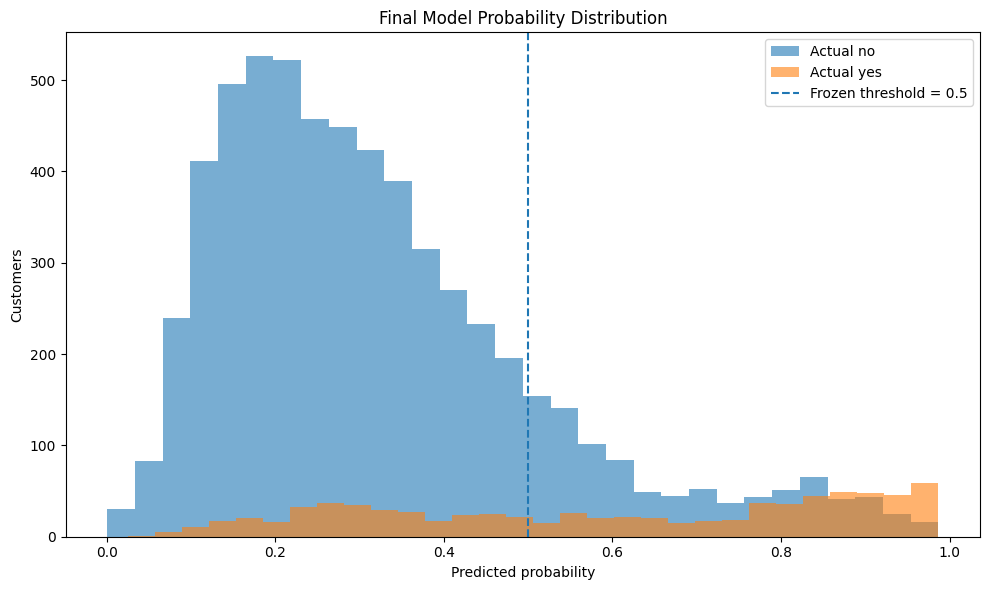

In [5]:
plt.figure(figsize=(10, 6))

plt.hist(
    pred.loc[pred.y_true == 0, "predicted_probability"],
    bins=30, alpha=0.6, label="Actual no"
)
plt.hist(
    pred.loc[pred.y_true == 1, "predicted_probability"],
    bins=30, alpha=0.6, label="Actual yes"
)

plt.axvline(0.5, linestyle="--", label="Frozen threshold = 0.5")
plt.xlabel("Predicted probability")
plt.ylabel("Customers")
plt.title("Final Model Probability Distribution")
plt.legend()
plt.tight_layout()
plt.savefig(PROB_PLOT, dpi=150, bbox_inches="tight")
plt.show()


## 3. Probability Bands

Measure actual subscription rate across predicted-probability bands.


In [6]:
bins = np.linspace(0, 1, 11)
labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(10)]

pred["probability_band"] = pd.cut(
    pred["predicted_probability"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

band_summary = pred.groupby(
    "probability_band",
    observed=False
).agg(
    samples=("y_true", "size"),
    actual_positive_rate=("y_true", "mean"),
    predicted_positive_rate=("y_pred", "mean"),
)

display(band_summary.round(4))


,samples,actual_positive_rate,predicted_positive_rate
probability_band,,,
0.0-0.1,366,0.0301,0.0
0.1-0.2,1523,0.0322,0.0
0.2-0.3,1528,0.0674,0.0
0.3-0.4,1205,0.0680,0.0
0.4-0.5,761,0.0946,0.0
0.5-0.6,452,0.1416,1.0
0.6-0.7,234,0.2479,1.0
0.7-0.8,213,0.3615,1.0
0.8-0.9,294,0.4626,1.0


## 4. Precision-Recall and ROC Curves

These are diagnostic curves for the already-frozen model. No new threshold is selected.


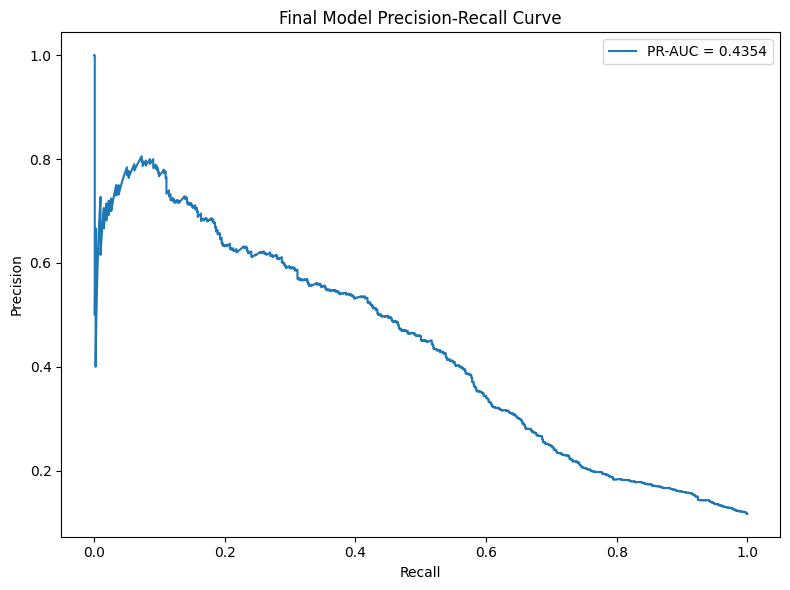

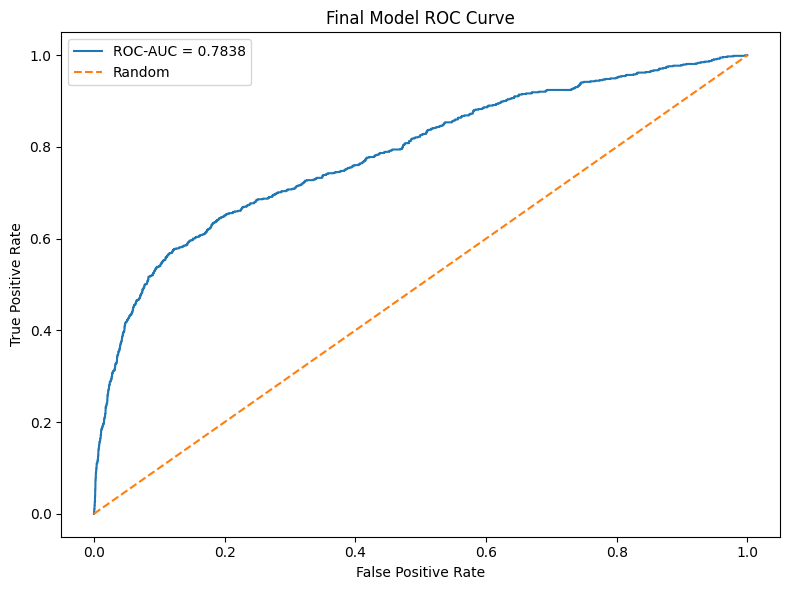

In [7]:
precision, recall, _ = precision_recall_curve(
    pred.y_true,
    pred.predicted_probability
)
pr_auc = average_precision_score(
    pred.y_true,
    pred.predicted_probability
)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Model Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.savefig(PR_PLOT, dpi=150, bbox_inches="tight")
plt.show()

fpr, tpr, _ = roc_curve(
    pred.y_true,
    pred.predicted_probability
)
roc_auc = roc_auc_score(
    pred.y_true,
    pred.predicted_probability
)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Model ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig(ROC_PLOT, dpi=150, bbox_inches="tight")
plt.show()


## 5. False Positives and False Negatives

Inspect the most confident mistakes first.


In [8]:
false_positives = pred[
    pred.error_type == "FP"
].sort_values(
    "predicted_probability",
    ascending=False
)

false_negatives = pred[
    pred.error_type == "FN"
].sort_values(
    "predicted_probability",
    ascending=False
)

print("False positives:", len(false_positives))
display(false_positives.head(20))

print("False negatives:", len(false_negatives))
display(false_negatives.head(20))


False positives: 923


,customer_index,y_true,predicted_probability,y_pred,error_type,probability_band
6114,40711,0,0.986650,1,FP,0.9-1.0
6767,45098,0,0.983362,1,FP,0.9-1.0
6472,43165,0,0.983111,1,FP,0.9-1.0
6480,43215,0,0.978567,1,FP,0.9-1.0
6499,43317,0,0.978538,1,FP,0.9-1.0
6543,43595,0,0.974468,1,FP,0.9-1.0
6592,43896,0,0.971547,1,FP,0.9-1.0
5098,33991,0,0.970805,1,FP,0.9-1.0
5958,39770,0,0.970070,1,FP,0.9-1.0
6502,43340,0,0.967473,1,FP,0.9-1.0


False negatives: 317


,customer_index,y_true,predicted_probability,y_pred,error_type,probability_band
5091,33909,1,0.499252,0,FN,0.4-0.5
6163,41083,1,0.498279,0,FN,0.4-0.5
4605,30533,1,0.495898,0,FN,0.4-0.5
5615,37349,1,0.491685,0,FN,0.4-0.5
4524,30105,1,0.491491,0,FN,0.4-0.5
5353,35746,1,0.489800,0,FN,0.4-0.5
5936,39583,1,0.486635,0,FN,0.4-0.5
2042,13473,1,0.484558,0,FN,0.4-0.5
5167,34366,1,0.482837,0,FN,0.4-0.5
3908,25925,1,0.481761,0,FN,0.4-0.5


## 6. Borderline and Confident Errors

Borderline predictions are closest to the frozen 0.5 threshold.

Confident errors are incorrect predictions farthest from the threshold.


In [9]:
pred["distance_from_threshold"] = (
    pred["predicted_probability"] - 0.5
).abs()

borderline = pred.sort_values(
    "distance_from_threshold"
).head(30)

confident_errors = pred[
    pred.error_type.isin(["FP", "FN"])
].copy()

confident_errors["confidence"] = np.where(
    confident_errors["predicted_probability"] >= 0.5,
    confident_errors["predicted_probability"],
    1 - confident_errors["predicted_probability"]
)

confident_errors = confident_errors.sort_values(
    "confidence",
    ascending=False
)

print("Borderline predictions:")
display(borderline)

print("Most confident errors:")
display(confident_errors.head(30))


Borderline predictions:


,customer_index,y_true,predicted_probability,y_pred,error_type,probability_band,distance_from_threshold
2895,19170,0,0.499978,0,TN,0.4-0.5,0.000022
822,5202,0,0.500185,1,FP,0.5-0.6,0.000185
5139,34219,0,0.500270,1,FP,0.5-0.6,0.000270
5146,34262,0,0.499542,0,TN,0.4-0.5,0.000458
5091,33909,1,0.499252,0,FN,0.4-0.5,0.000748
2011,13316,0,0.500976,1,FP,0.5-0.6,0.000976
2848,18882,0,0.501028,1,FP,0.5-0.6,0.001028
4824,31982,0,0.501123,1,FP,0.5-0.6,0.001123
2338,15370,0,0.498775,0,TN,0.4-0.5,0.001225
3036,20133,0,0.498623,0,TN,0.4-0.5,0.001377


Most confident errors:


,customer_index,y_true,predicted_probability,y_pred,error_type,probability_band,distance_from_threshold,confidence
6114,40711,0,0.986650,1,FP,0.9-1.0,0.486650,0.986650
6767,45098,0,0.983362,1,FP,0.9-1.0,0.483362,0.983362
6472,43165,0,0.983111,1,FP,0.9-1.0,0.483111,0.983111
6480,43215,0,0.978567,1,FP,0.9-1.0,0.478567,0.978567
6499,43317,0,0.978538,1,FP,0.9-1.0,0.478538,0.978538
532,3324,1,0.025439,0,FN,0.0-0.1,0.474561,0.974561
6543,43595,0,0.974468,1,FP,0.9-1.0,0.474468,0.974468
6592,43896,0,0.971547,1,FP,0.9-1.0,0.471547,0.971547
5098,33991,0,0.970805,1,FP,0.9-1.0,0.470805,0.970805
5958,39770,0,0.970070,1,FP,0.9-1.0,0.470070,0.970070


## 7. Customer Feature Context

Load the saved graph and join customer-node features to the final test predictions.

If feature names are unavailable in metadata, preserve feature indices rather than inventing semantic names.


In [ ]:
import torch

try:
    try:
        graph = torch.load(
            GRAPH,
            map_location="cpu",
            weights_only=False,
        )
    except TypeError:
        graph = torch.load(
            GRAPH,
            map_location="cpu",
        )
except TypeError:
    graph = torch.load(GRAPH, map_location="cpu")

customer_x = graph["customer"].x.detach().cpu().numpy()

# Use metadata names only if explicitly available.
feature_names = None
for key in ["customer_feature_names", "feature_names", "customer_features"]:
    if isinstance(graph, dict) and key in graph:
        if isinstance(graph[key], list):
            feature_names = graph[key]
            break

if feature_names is None:
    feature_names = [
        f"customer_feature_{i}"
        for i in range(customer_x.shape[1])
    ]

if len(feature_names) != customer_x.shape[1]:
    feature_names = [
        f"customer_feature_{i}"
        for i in range(customer_x.shape[1])
    ]

features = pd.DataFrame(customer_x, columns=feature_names)
features["customer_index"] = np.arange(len(features))

analysis = pred.merge(
    features,
    on="customer_index",
    how="left",
    validate="one_to_one"
)

assert len(analysis) == len(pred)

print("Merged analysis shape:", analysis.shape)
display(analysis.head())


NameError: name 'torch' is not defined

## 8. Error-Group Feature Summary

Compare available numerical customer-node features across TN, FP, FN and TP.

This is descriptive analysis only.


In [ ]:
numeric_features = [
    c for c in features.columns
    if c != "customer_index"
    and pd.api.types.is_numeric_dtype(features[c])
]

if numeric_features:
    group_means = (
        analysis
        .groupby("error_type")[numeric_features]
        .mean()
        .T
    )
    display(group_means.round(4))
else:
    print("No numerical customer feature columns available.")


## 9. Save Error Analysis Artifacts

These artifacts will be useful for the explainability and backend stages.


In [ ]:
analysis.to_csv(ERROR_TABLE, index=False)

analysis_summary = {
    **summary,
    "final_metrics": final_metrics,
    "frozen_threshold": 0.5,
    "model_status": "FINAL_FROZEN_MODEL",
}

with open(SUMMARY, "w", encoding="utf-8") as f:
    json.dump(analysis_summary, f, indent=2)

print("Saved:", ERROR_TABLE)
print("Saved:", SUMMARY)
print("Saved:", PROB_PLOT)
print("Saved:", PR_PLOT)
print("Saved:", ROC_PLOT)


# 10. Final Verification

Notebook 07 does not modify the model.

Required:
- prediction integrity passed
- TN/FP/FN/TP analyzed
- probability distribution generated
- PR/ROC curves generated
- false positives and false negatives inspected
- feature context joined
- artifacts saved

### STOP

Do not tune the frozen model using this analysis.

Next: **GraphSAGE / heterogeneous-graph explainability** using an explanation method appropriate to the architecture.


In [ ]:
for p in [ERROR_TABLE, SUMMARY, PROB_PLOT, PR_PLOT, ROC_PLOT]:
    assert p.exists(), f"Missing output: {p}"

assert pred.customer_index.is_unique
assert pred.y_true.isin([0,1]).all()
assert pred.y_pred.isin([0,1]).all()
assert pred.predicted_probability.between(0,1).all()

print("=" * 85)
print("NOTEBOOK 07 VERIFICATION PASSED")
print("=" * 85)
print("Test samples:", len(pred))
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)
print("Final PR-AUC:", f"{final_metrics['pr_auc']:.6f}")
print("Final ROC-AUC:", f"{final_metrics['roc_auc']:.6f}")
print("Final F1:", f"{final_metrics['f1']:.6f}")
print("Model status: FINAL_FROZEN_MODEL")
print("=" * 85)
